# Introduction
The following four topics will be discussed

- Financial Data
  -  data import
  -  summary statistics
  -  resampling
-  Rolling Statistics
  -  moving average
  
- Correlation Analysis
  - S&P 500 index and Vix relationship
  - Question: "In economics did we usually use CAUSALITY?"
     - econ/finance: time series
     - MLearning/DeepLearning: Whitening/Explainable ML/DL 
        - econ policy/finance: IMPORTANT!!!! 
        - 왜 경제정책이 실패했니? 왜 성공했니? 투자수익률이 기대 이상이니? 
   - TSLA/Palantir/Bitmine; ETHM/BTH/SOL 
     - 왜 상승하나요? 미국의 AI산업과 무슨 관계가 있나요? 
     - BTH: 20만불, 100만불? 
       - 희소성? 설명이 없어?  
  - economics 
    - model: causality (y increase, consumption follow, y increase)
- High Frequency data

## Data import from web: <font color='yellow'>Here yahoo finance</font>


# rhetoric 
 - professor; jupyter notebook: trying to covey lecture easily 
   - notebook+IDE(cursor): high token usage / high ram memory 
 - recommend: IDE + py file  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.core.common.is_list_like = pd.api.types.is_list_like
from pandas_datareader import data as pdr
import yfinance as yf
# if wish to override hassle with pandas then use yf.download()

## Data import: from yahoo finance

In [ ]:
# tickers
tickers = ['AAPL', 'MSFT', 'IBM', 'GOOG', "TSLA", "^GSPC", "^IXIC", "BTC-USD", "ETH-USD", "^KS11"]
# ^GSPC: S&P 500 index
# ^IXIC: NASDAQ index
# ^KS11: KOSPI index
# BTC-USD: Bitcoin price
# ETH-USD: Ethereum price

# Google NOTEBOOK LLM


In [4]:
# Download KOSPI data
kospi = yf.download('^KS11', "2020-01-01")
print("\nKOSPI Data Sample:")
kospi.head()


[*********************100%***********************]  1 of 1 completed


KOSPI Data Sample:


Price,Close,High,Low,Open,Volume
Ticker,^KS11,^KS11,^KS11,^KS11,^KS11
Date,,,,,
2020-01-02,2175.169922,2202.320068,2171.840088,2201.209961,494700
2020-01-03,2176.459961,2203.379883,2165.389893,2192.580078,631600
2020-01-06,2155.070068,2164.419922,2149.949951,2154.969971,592700
2020-01-07,2175.540039,2181.620117,2164.270020,2166.600098,568200
2020-01-08,2151.310059,2162.320068,2137.719971,2156.270020,913800


In [5]:
ticker = tickers[0]
aapl = yf.download('AAPL', "2020-01-01")

[*********************100%***********************]  1 of 1 completed


In [ ]:
aapl.columns = [x[0].lower() for x in aapl.columns]
aapl.head()

,close,high,low,open,volume
Date,,,,,
2020-01-02,72.538528,72.598907,71.292319,71.545905,135480400
2020-01-03,71.833298,72.594063,71.608692,71.765674,146322800
2020-01-06,72.405678,72.444321,70.703012,70.954188,118387200
2020-01-07,72.065140,72.671333,71.845362,72.415330,108872000
2020-01-08,73.224396,73.526287,71.768071,71.768071,132079200


# Volume 
- private information extraction source 
  - trading records abnormal (such as MA(V, 20)< volume_t * 5)
  - new information flows: good/bad/short/long/no_information? 
- Rational expectation? 
  - use all available information 
  - all investor/economic agents have the same information,why trading happen? ---> Heterogenous? 
  - trading volume $\uparrow$ future expectation different
- In competitive equilibrium:  buy=(1000KRW, 100units), sell = (1000KRW, 100units)
  - equilibrium price?1000KRW
  - equilibrium volume: 100 units?   maximum tradable units 
    - at 1000KRW, both buyer and seller no difference b/w holding money and buying/selling goods 

## Data export as 'csv' file

In [ ]:
#aapl.to_csv("aapl.csv")

## Data import from csv file

In [ ]:
# import

#AAPL = pd.read_csv("c:/python/data/pff/AAPL.csv")


In [ ]:
# download data and change column name

df = pd.DataFrame()
for ticker in tickers:
    tmp = yf.download(ticker, "2020-01-01")['Close']
    tmp.columns =[x.lower() for x in tmp.columns]
    df[ticker]=tmp


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [7]:
df.head()

,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC,BTC-USD,ETH-USD,^KS11
Date,,,,,,,,,,
2020-01-02,72.538528,152.791107,100.565201,67.903816,28.684000,3257.850098,9092.190430,6985.470215,127.410179,2175.169922
2020-01-03,71.833313,150.888596,99.763168,67.570580,29.534000,3234.850098,9020.769531,7344.884277,134.171707,2176.459961
2020-01-06,72.405685,151.278595,99.584930,69.236702,30.102667,3246.280029,9071.469727,7769.219238,144.304153,2155.070068
2020-01-07,72.065147,149.899292,99.651749,69.193489,31.270666,3237.179932,9068.580078,8163.692383,143.543991,2175.540039
2020-01-08,73.224426,152.286926,100.483498,69.738770,32.809334,3253.050049,9129.240234,8079.862793,141.258133,2151.310059


In [ ]:
# save for later use

df.to_csv("your_directory")

# Preliminary Analysis


## Basic Statistics

In [8]:
df.describe()

,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC,BTC-USD,ETH-USD,^KS11
count,1444.000000,1444.000000,1444.000000,1444.000000,1444.000000,1444.000000,1444.000000,1443.000000,1443.000000,1363.000000
mean,160.514210,308.548524,143.438341,127.763390,228.094549,4486.868158,14201.038155,44798.419767,2104.694438,2626.778466
std,45.674783,95.583998,53.296237,39.012280,88.885166,938.285703,3294.222794,29885.540571,1164.271494,347.464874
min,54.316933,129.171295,71.112709,52.471920,24.081333,2237.399902,6860.669922,4970.788086,110.605873,1457.640015
25%,130.447456,235.046612,107.698185,98.274973,180.517494,3892.050049,11693.974854,21235.705078,1373.168213,2417.380005
50%,160.930786,290.049988,119.391335,128.546562,231.901672,4356.745117,13780.280273,38286.027344,1961.280762,2582.179932
75%,191.020992,398.621231,173.759537,154.698853,282.279991,5182.137695,16249.879639,61679.908203,2986.746948,2822.430054
max,258.103729,534.760925,292.800354,255.240005,479.859985,6693.750000,22788.980469,123344.062500,4831.348633,3486.189941


In [9]:
df.quantile(q=0.5)

AAPL         160.930786
MSFT         290.049988
IBM          119.391335
GOOG         128.546562
TSLA         231.901672
^GSPC       4356.745117
^IXIC      13780.280273
BTC-USD    38286.027344
ETH-USD     1961.280762
^KS11       2582.179932
Name: 0.5, dtype: float64

## Plotting

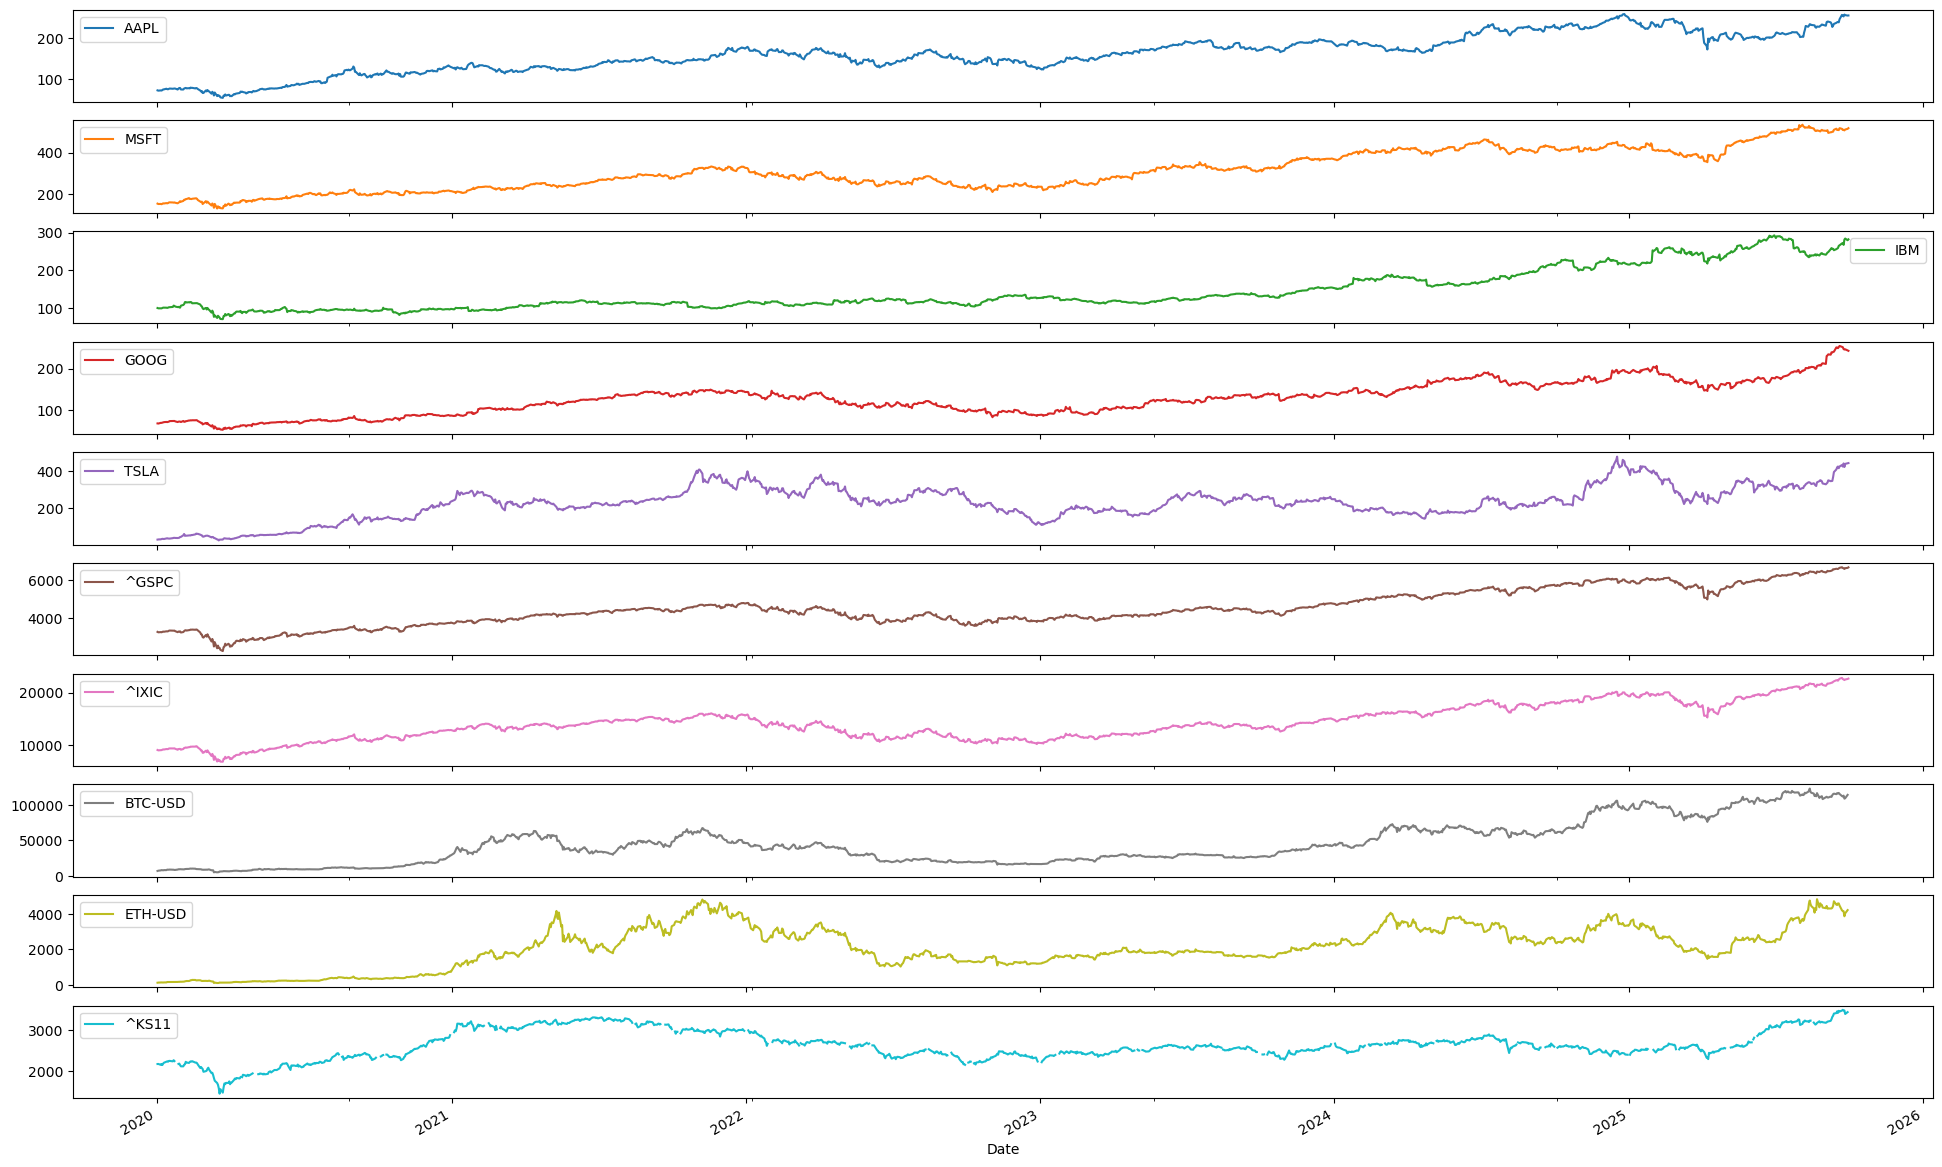

In [10]:
#data_close.plot()
df.plot(subplots=True, figsize=(24,16))
plt.show()

<Axes: xlabel='Date'>

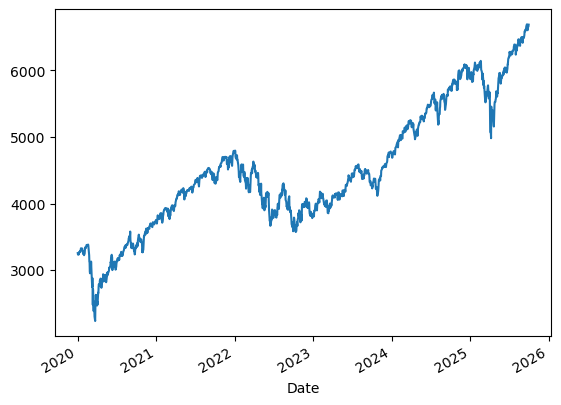

In [ ]:
df["^GSPC"].plot()

# recently question or speculate on "collapse" in US stock market?
# WHY? 
## 1. 미국의 장단기 금리 역전(short-term interest rate > long-term interest rate)
##


## Rate of return related

In [ ]:
# percentage return

df.pct_change().dropna().head()


,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC,BTC-USD,ETH-USD,^KS11
Date,,,,,,,,,,
2020-01-03,-0.009722,-0.012452,-0.007975,-0.004907,0.029633,-0.007060,-0.007855,0.051452,0.053069,0.000593
2020-01-06,0.007968,0.002585,-0.001787,0.024658,0.019255,0.003533,0.005620,0.057773,0.075519,-0.009828
2020-01-07,-0.004703,-0.009118,0.000671,-0.000624,0.038801,-0.002803,-0.000319,0.050774,-0.005268,0.009499
2020-01-08,0.016087,0.015928,0.008347,0.007881,0.049205,0.004902,0.006689,-0.010269,-0.015924,-0.011137
2020-01-09,0.021241,0.012493,0.010568,0.011044,-0.021945,0.006655,0.008127,-0.024851,-0.016133,0.016334


$$
100 \times {{p_t - p_{t-1}}\over{{p_{t-1}}}}
$$

In [ ]:
# log return

np.log(df/df.shift(1)).dropna().head()

,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
Date,,,,,,,
2020-01-03,-0.009770,-0.012530,-0.008007,-0.004920,0.029203,-0.007085,-0.007886
2020-01-06,0.007937,0.002582,-0.001788,0.024358,0.019072,0.003527,0.005605
2020-01-07,-0.004714,-0.009160,0.000671,-0.000624,0.038067,-0.002807,-0.000319
2020-01-08,0.015958,0.015803,0.008312,0.007849,0.048033,0.004890,0.006667
2020-01-09,0.021018,0.012416,0.010513,0.010984,-0.022189,0.006633,0.008094


In [14]:
# differnce

df.diff().dropna().head()

,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC,BTC-USD,ETH-USD,^KS11
Date,,,,,,,,,,
2020-01-03,-0.705215,-1.902512,-0.802032,-0.333237,0.850000,-23.000000,-71.420898,359.414062,6.761528,1.290039
2020-01-06,0.572372,0.389999,-0.178238,1.666122,0.568666,11.429932,50.700195,424.334961,10.132446,-21.389893
2020-01-07,-0.340538,-1.379303,0.066818,-0.043213,1.167999,-9.100098,-2.889648,394.473145,-0.760162,20.469971
2020-01-08,1.159279,2.387634,0.831749,0.545280,1.538668,15.870117,60.660156,-83.829590,-2.285858,-24.229980
2020-01-09,1.555328,1.902527,1.061928,0.770210,-0.720001,21.649902,74.189453,-200.791504,-2.278931,35.139893


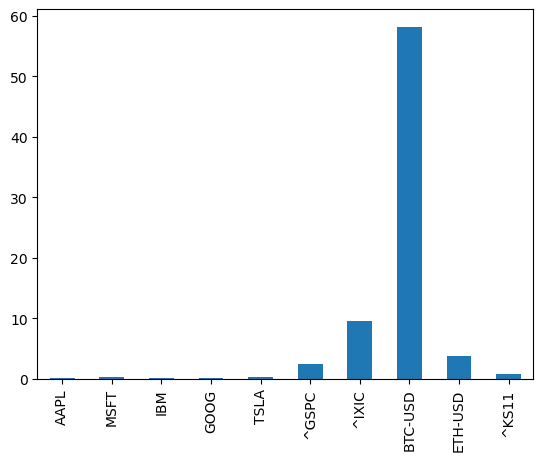

In [15]:
# plot difference mean histogram

df.diff().dropna().mean().plot(kind='bar');

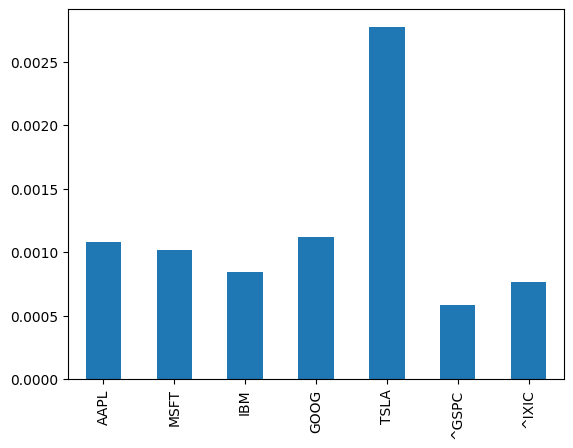

In [ ]:
df.pct_change().dropna().mean().plot(kind='bar');

<Axes: xlabel='Date'>

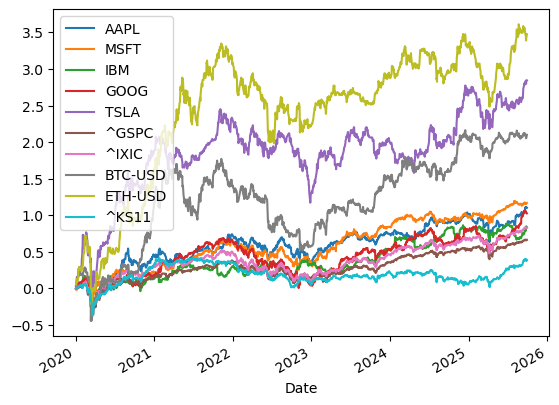

In [ ]:
ret = np.log(df/df.shift(1)).dropna()
ret.cumsum().plot()

# MicroStrategy, BitMINER

<Axes: xlabel='Date'>

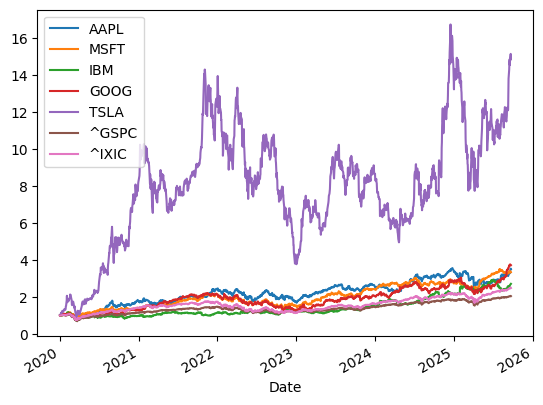

In [ ]:
ret.cumsum().apply(np.exp).plot()   # why exp?

**Cumulative return**
\begin{align*}
\exp\left[log \left(\ 1+ \frac{p_t - p_{t-1}}{p_{t-1}}    \right).cumsum  \right] -1
\end{align*}  

<Axes: xlabel='Date'>

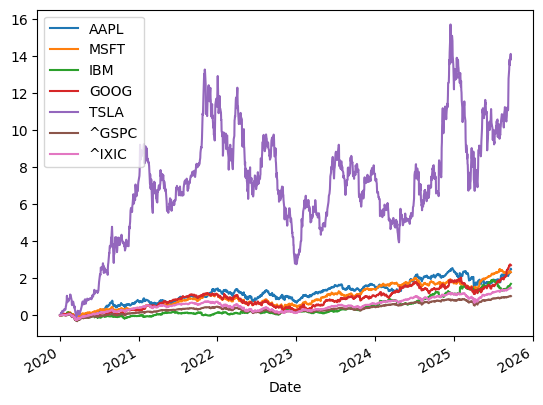

In [ ]:
ret = df.pct_change()
cum_ret = np.exp(np.log(1+ret).cumsum())-1
cum_ret.plot()

# Resampling

In [ ]:
df.resample('1w', label='right').first().head()
# week: M-F, else 
# don't do average: weekly data: average of 5 days? NO  
## df.close[:i-5]j.mean()

/tmp/ipython-input-750673998.py:1: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  df.resample('1w', label='right').first().head()


,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
Date,,,,,,,
2020-01-05,72.538528,152.791138,100.565186,67.903824,28.684000,3257.850098,9092.190430
2020-01-12,72.405670,151.278625,99.584961,69.236694,30.102667,3246.280029,9071.469727
2020-01-19,76.550049,155.321472,101.441460,71.472389,34.990665,3288.129883,9273.929688
2020-01-26,76.455849,158.384552,103.349991,73.715546,36.480000,3320.790039,9370.809570
2020-02-02,74.615547,154.370209,102.941544,71.207710,37.201332,3243.629883,9139.309570


In [ ]:
df.resample('1w', label='right').last().head()

/tmp/ipython-input-1009130987.py:1: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  df.resample('1w', label='right').last().head()


,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
Date,,,,,,,
2020-01-05,71.833282,150.888565,99.763168,67.570587,29.534000,3234.850098,9020.769531
2020-01-12,74.948830,153.476074,101.508316,71.000633,31.876667,3265.350098,9178.860352
2020-01-19,76.977524,158.955276,102.711365,73.516403,34.033333,3329.620117,9388.940430
2020-01-26,76.876091,156.995697,104.382240,72.837051,37.654667,3295.469971,9314.910156
2020-02-02,74.750801,161.932755,106.736320,71.224091,43.371334,3225.520020,9150.940430


In [ ]:
df.index.weekday

Index([3, 4, 0, 1, 2, 3, 4, 0, 1, 2,
       ...
       2, 3, 4, 0, 1, 2, 3, 4, 0, 1],
      dtype='int32', name='Date', length=1439)

In [ ]:
df.resample('M', label='left', closed='left').last().head()

/tmp/ipython-input-4221010652.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M', label='left', closed='left').last().head()


,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
Date,,,,,,,
2019-12-31,78.218895,164.358414,101.567719,72.297256,42.720669,3283.659912,9298.929688
2020-01-31,66.176735,154.534332,97.660851,66.511345,44.532665,2954.219971,8567.370117
2020-02-29,61.686050,152.836395,84.739441,56.951267,33.475334,2626.649902,7774.149902
2020-03-31,69.655510,169.242767,96.565300,66.618118,53.367332,2939.510010,8914.709961
2020-04-30,77.177322,175.281067,94.978317,70.960403,55.666668,3044.310059,9489.870117


/tmp/ipython-input-1020566399.py:3: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  ax = ret.cumsum().resample('m').last().plot()


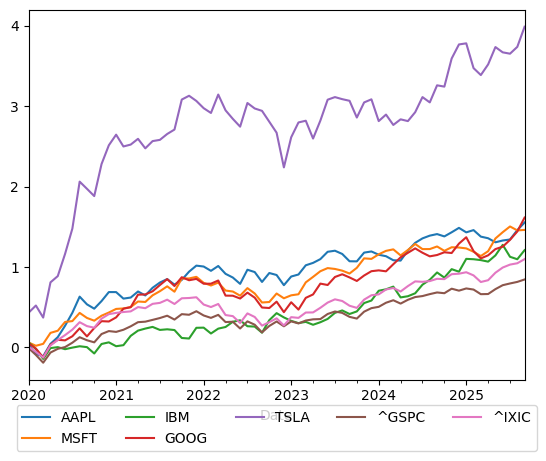

In [ ]:
#ret.index = pd.to_datetime(ret.index)

ax = ret.cumsum().resample('m').last().plot()
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=5)
#ax.legend(loc='center left')

#ret.cumsum().resample('m').last().plot(figsize=(16,9))

# Rolling Statistics

In [ ]:
#df['min'] = df.rolling(window=20).min()
#df['max'] = df.rolling(window=20).max()
tsla_mean = df['TSLA'].rolling(20).mean()

<Axes: xlabel='Date'>

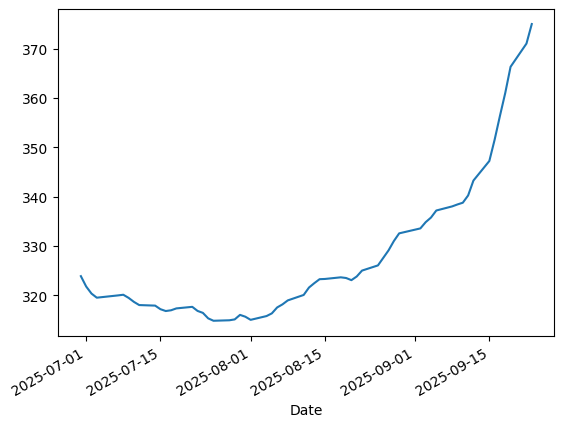

In [ ]:
tsla_mean[-60:].plot()

In [ ]:
df2 = df['TSLA'].copy()
df2 = pd.DataFrame(df2)
df2.index =  pd.to_datetime(df.index)
df2.columns = ['close']
df2 = df2.dropna()

In [ ]:
df2.head()

,close,sma20
Date,,
2020-01-02,28.684000,NaN
2020-01-03,29.534000,NaN
2020-01-06,30.102667,NaN
2020-01-07,31.270666,NaN
2020-01-08,32.809334,NaN


In [ ]:
df2['sma20'] = df2['close'].rolling(20).mean()
df2['sma60'] = df2['close'].rolling(60).mean()

In [ ]:
df2['position'] = list(map(lambda x,y: [-1,1][x>y], df2['sma20'], df2['sma60']))
df2['position2'] = np.where(df2['sma20']>df2['sma60'], 1, -1)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

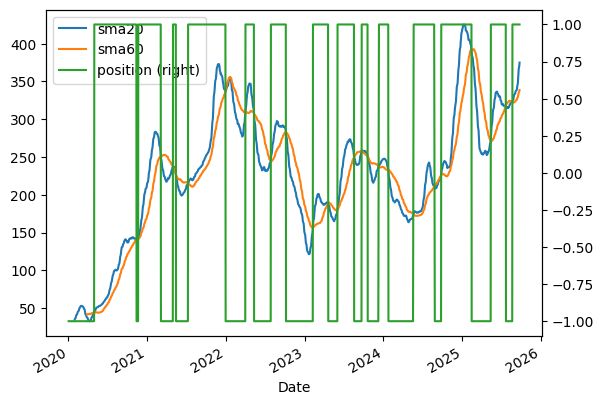

In [ ]:
%matplotlib inline
df2[['sma20', 'sma60', 'position']].plot(secondary_y = 'position')
plt.show()

# Correlation Analysis

In [ ]:
vix = yf.download('^VIX', "2020-01-01")
vix = vix['Close']
vix.columns =['VIX']
df['VIX']= vix

/tmp/ipython-input-2476782146.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download('^VIX', "2020-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
data_index = df[['^GSPC', 'VIX']]
data_index = data_index.dropna()
data_index.head()

,^GSPC,VIX
Date,,
2020-01-02,3257.850098,12.47
2020-01-03,3234.850098,14.02
2020-01-06,3246.280029,13.85
2020-01-07,3237.179932,13.79
2020-01-08,3253.050049,13.45


<Axes: xlabel='Date'>

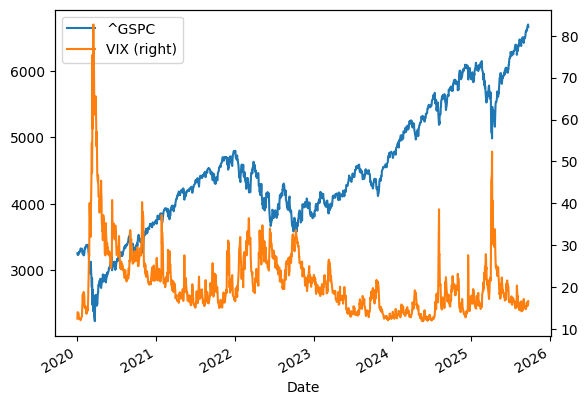

In [ ]:
data_index.plot(secondary_y='VIX')

In [ ]:
ret_index = data_index.pct_change()
ret_index = ret_index.dropna()

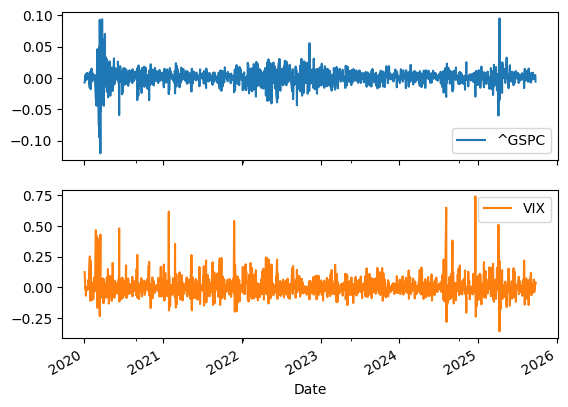

In [ ]:
%matplotlib inline

ret_index.plot(subplots=True);

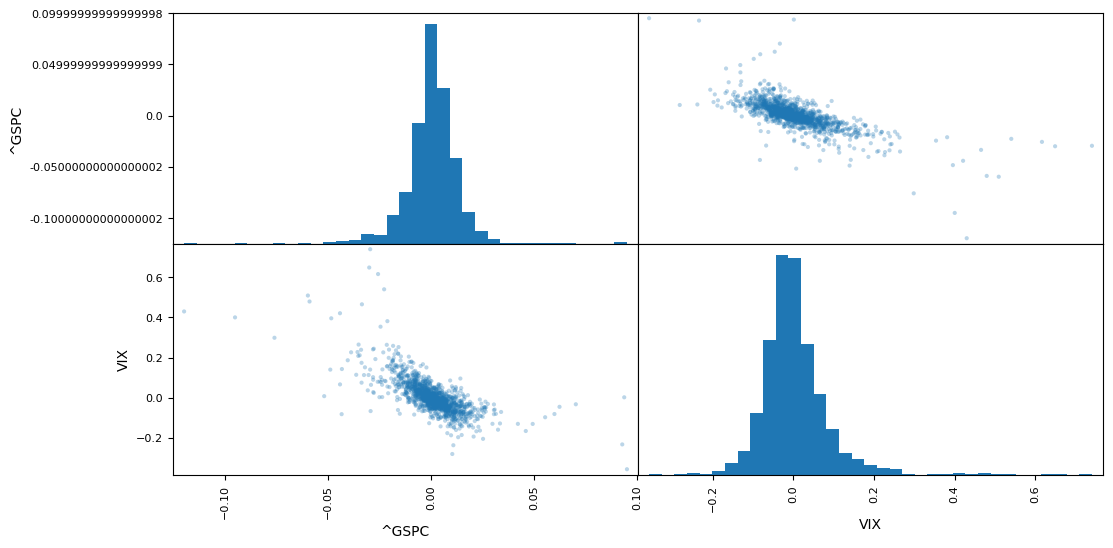

In [ ]:
pd.plotting.scatter_matrix(ret_index, diagonal='hist', figsize=(12,6), hist_kwds={'bins': 35}, alpha=0.3);

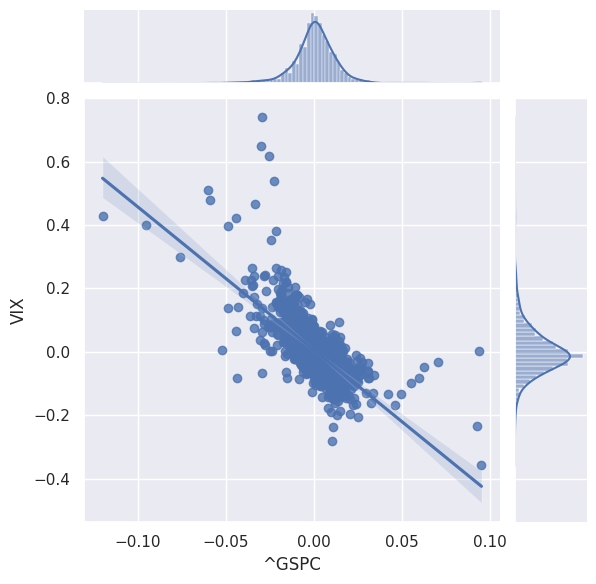

In [ ]:
import seaborn as sns;  sns.set()

sns.jointplot(x='^GSPC', y='VIX', data=ret_index, kind='reg')

In [ ]:
rets_corr = ret_index.corr()
rets_corr

,^GSPC,VIX
^GSPC,1.000000,-0.714464
VIX,-0.714464,1.000000


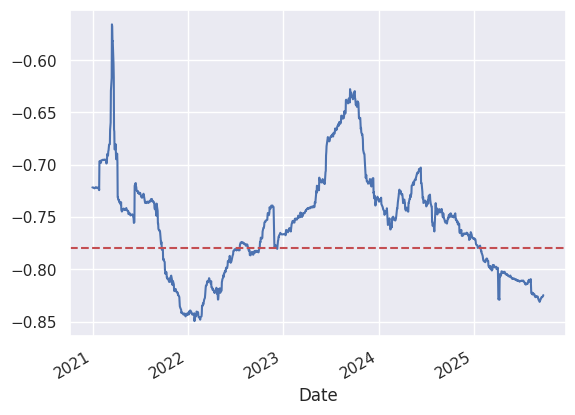

In [ ]:
ax= ret_index['^GSPC'].rolling(window=252).corr(ret_index['VIX']).plot()
#ax.axvline(rets_corr.iloc[0,1])
ax.axhline(y=-0.78, c='r', ls='--')

# Volatility Analysis

We'll analyze S&P 500 volatility using two approaches:
1. Simple squared returns as volatility proxy
2. ARCH/GARCH model for conditional volatility estimation


In [ ]:
# Changing Default Plotting Method in Pandas

# Method 1: Set the plotting backend globally
import pandas as pd
import matplotlib.pyplot as plt

# You can change the backend using matplotlib
plt.switch_backend('Agg')  # or 'Qt5Agg', 'TkAgg', etc.

# Method 2: Use pandas plotting options
pd.options.plotting.backend = 'matplotlib'  # default
# pd.options.plotting.backend = 'plotly'  # for interactive plots
# pd.options.plotting.backend = 'bokeh'   # for Bokeh plots

# Method 3: Set matplotlib style
plt.style.use('default')  # or 'seaborn', 'ggplot', etc.

# Method 4: Configure pandas plotting parameters
pd.options.plotting.matplotlib.register_converters = True


In [ ]:
# Example: Change to Plotly backend for interactive plots
# First install plotly if not already installed
# !pip install plotly

# Set plotly as backend
# pd.options.plotting.backend = 'plotly'

# Example usage with different backends:
# df.plot()  # Will use the backend you set above

# You can also specify backend per plot:
# df.plot(backend='plotly')  # for interactive plots
# df.plot(backend='matplotlib')  # for static plots


In [11]:
# Practical Example: Setting up different plotting environments

# For Jupyter notebooks, you might want:
%matplotlib inline  # for static plots in notebook
# %matplotlib widget  # for interactive plots in notebook

# For different plotting libraries:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style("darkgrid")  # or "whitegrid", "dark", "white", "ticks"
sns.set_palette("husl")  # or "Set1", "Set2", etc.

# Example with our financial data
# df['^KS11'].plot(title='KOSPI Index', figsize=(12, 6))


UsageError: unrecognized arguments: # for static plots in notebook


In [2]:
# Install arch package if not already installed
import sys
!{sys.executable} -m pip install arch

# Import required packages
import arch
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.1/985.1 kB 18.9 MB/s eta 0:00:0031m18.9 MB/s eta 0:00:01


In [ ]:
# Calculate returns and squared returns for S&P 500
sp500_returns = np.log(df['^GSPC']/df['^GSPC'].shift(1)).dropna()
sp500_squared_returns = sp500_returns**2

# Plot squared returns
plt.figure(figsize=(15, 6))
plt.plot(sp500_squared_returns.index, sp500_squared_returns.values, label='Squared Returns', alpha=0.6)
plt.title('S&P 500 Volatility (Squared Returns)')
plt.xlabel('Date')
plt.ylabel('Squared Returns')
plt.legend()
plt.grid(True)
plt.show()

# Plot 30-day rolling window of squared returns for smoother visualization
plt.figure(figsize=(15, 6))
plt.plot(sp500_squared_returns.rolling(window=30).mean(), label='30-day Rolling Squared Returns', color='darkblue')
plt.title('S&P 500 Volatility (30-day Rolling Window of Squared Returns)')
plt.xlabel('Date')
plt.ylabel('Rolling Squared Returns')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Fit GARCH(1,1) model
garch_model = arch_model(sp500_returns*100, vol='Garch', p=1, q=1)  # multiply by 100 to get percentage returns
garch_results = garch_model.fit(disp='off')

# Get conditional volatility
conditional_vol = garch_results.conditional_volatility / 100  # convert back to decimal

# Plot GARCH volatility
plt.figure(figsize=(15, 6))
plt.plot(sp500_returns.index, conditional_vol, label='GARCH(1,1) Volatility', color='darkred')
plt.title('S&P 500 Volatility (GARCH Model)')
plt.xlabel('Date')
plt.ylabel('Conditional Volatility')
plt.legend()
plt.grid(True)
plt.show()

# Print model summary
print("\nGARCH Model Summary:")
print(garch_results.summary().tables[1])


In [ ]:
# Compare both volatility measures
plt.figure(figsize=(15, 8))
plt.plot(sp500_squared_returns.rolling(window=30).mean()**0.5, 
         label='Rolling Volatility (Squared Returns)', 
         alpha=0.7)
plt.plot(sp500_returns.index, conditional_vol, 
         label='GARCH(1,1) Volatility', 
         alpha=0.7)
plt.title('S&P 500 Volatility Comparison')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()
